In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import norm

def symmetrize(A):
    return 0.5 * (A + A.T)

def make_dataset(n, d, rng):
    return rng.uniform(-1, 1, size=(n, d))

def bisecting_hyperplane(x_i, x_j):
    diff = x_i - x_j
    nrm = np.linalg.norm(diff)
    if nrm < 1e-12:
        w = np.zeros_like(diff); w[0] = 1.0
        return w, 0.0
    w = diff / nrm
    b = (np.dot(x_j, x_j) - np.dot(x_i, x_i)) / (2 * nrm)
    return w, b

def probit_prob(x_i, x_j, x_t, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    return norm.cdf((np.dot(x_t, w) + b) / sigma_eps)

def query_oracle(x_i, x_j, x_t, sigma_eps, rng):
    p = probit_prob(x_i, x_j, x_t, sigma_eps)
    return 0 if rng.random() < p else 1

def sample_mirror(mu, Sigma, X, used, rng):
    Sigma = symmetrize(Sigma)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    w_star = eigvecs[:, -1]
    b_star = -np.dot(w_star, mu)
    z1 = rng.multivariate_normal(mu, Sigma)
    z2 = z1 - 2 * (np.dot(w_star, z1) + b_star) * w_star
    def nearest(z, exclude):
        diffs = X - z
        d2 = np.einsum('nd,nd->n', diffs, diffs)
        for k in exclude:
            d2[k] = np.inf
        return int(np.argmin(d2))
    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    return i, j

def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    if y == 1:
        w = -w; b = -b
    Sw = Sigma @ w
    wSw = float(w @ Sw)
    denom = np.sqrt(wSw + sigma_eps**2)
    mu_w = float(mu @ w)
    g = (mu_w + b) / denom
    phi_g = norm.pdf(g)
    Phi_g = max(norm.cdf(g), 1e-12)
    alpha = phi_g / (Phi_g * denom)
    beta = -alpha * (g / denom + alpha)
    tau = -beta / (1 + beta * wSw)
    nu = (alpha - beta * (mu_w + b)) / (1 + beta * wSw)
    Sigma_new = Sigma - (tau / (1 + tau * wSw)) * np.outer(Sw, Sw)
    Sigma_new = symmetrize(Sigma_new)
    mu_new = mu + (nu - b * tau - tau * mu_w) * (Sigma_new @ w)
    return mu_new, Sigma_new

SIGMA_EPS = 0.20
print("helpers loaded")

helpers loaded


In [20]:
def gauss_search_verbose(X, target_idx, sigma_eps, max_queries, rng, stop_on="in_query"):
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    history = {
        "mu": [mu.copy()],
        "Sigma": [Sigma.copy()],
        "queries": [],
        "answers": [],
        "step_stopped": None,
    }
    for step in range(max_queries):
        if stop_on == "argmax":
            diffs = X - mu
            Sigma_inv = np.linalg.inv(Sigma)
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                history["step_stopped"] = step
                break
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        y = query_oracle(X[i], X[j], X[target_idx], sigma_eps, rng)
        history["queries"].append((i, j))
        history["answers"].append(y)
        if stop_on == "in_query" and target_idx in (i, j):
            history["step_stopped"] = step + 1
            break
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
        history["mu"].append(mu.copy())
        history["Sigma"].append(Sigma.copy())
    return history

# smoke test
rng = np.random.default_rng(seed=42)
X = make_dataset(n=200, d=2, rng=rng)
target_idx = int(rng.integers(0, 200))
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100, rng=rng, stop_on="in_query")
print(f"target: {target_idx} at {X[target_idx]}")
print(f"steps taken: {history['step_stopped']}")
print(f"snapshots logged: {len(history['mu'])}")
print(f"final mu: {history['mu'][-1]}")
print(f"final Sigma diag: {np.diag(history['Sigma'][-1])}")

target: 2 at [-0.8116453  0.9512447]
steps taken: 3
snapshots logged: 3
final mu: [-0.70958753  0.88197096]
final Sigma diag: [0.39459628 0.37739904]


In [21]:
# find a run with a reasonable number of steps for visualization
rng = np.random.default_rng(seed=42)
X = make_dataset(n=200, d=2, rng=rng)

runs = []
for trial in range(50):
    rng_trial = np.random.default_rng(seed=1000 + trial)
    target_idx = int(rng_trial.integers(0, 200))
    h = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100, rng=rng_trial, stop_on="in_query")
    runs.append((h["step_stopped"], target_idx, trial, h))

runs.sort(key=lambda r: r[0])
lengths = [r[0] for r in runs]
print(f"step distribution: min={lengths[0]}, median={lengths[25]}, max={lengths[-1]}")
print(f"length percentiles: p25={lengths[12]}, p50={lengths[25]}, p75={lengths[37]}")

# pick something in the p60-p75 range: long enough to show convergence, not pathological
chosen = runs[32]
steps, target_idx, trial, history = chosen
print(f"\nchosen trial {trial}: target={target_idx}, steps={steps}, snapshots={len(history['mu'])}")

step distribution: min=1, median=10, max=19
length percentiles: p25=6, p50=10, p75=13

chosen trial 45: target=142, steps=11, snapshots=11


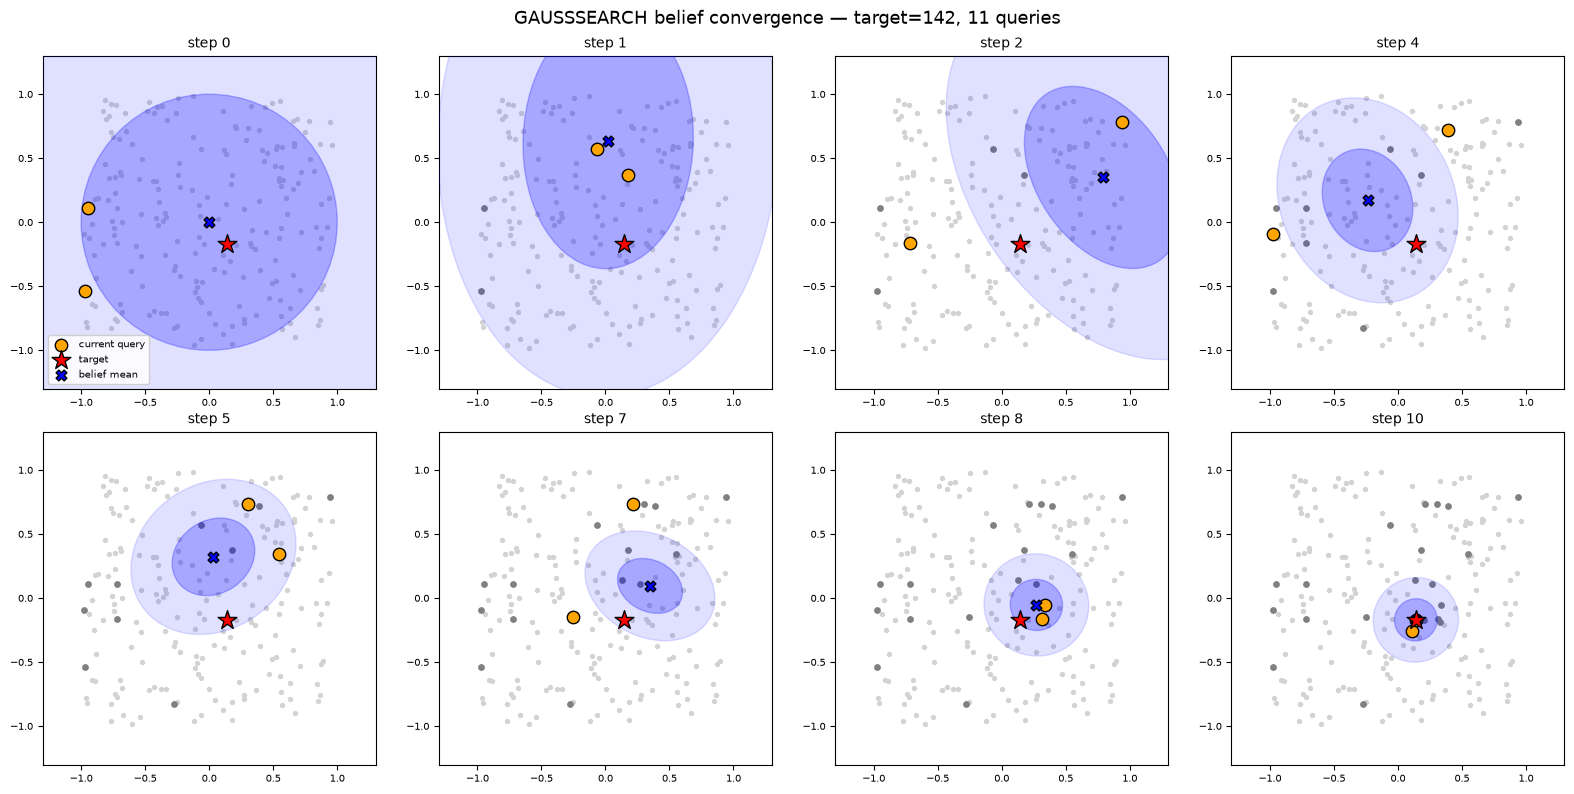

In [22]:
def plot_belief_step(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, step_num):
    # all items as faint dots
    ax.scatter(X[:, 0], X[:, 1], s=8, c='lightgray', zorder=1)
    
    # used items (past queries) slightly darker
    used = set()
    for (i, j) in queries_so_far:
        used.add(i); used.add(j)
    if used:
        used_arr = np.array(list(used))
        ax.scatter(X[used_arr, 0], X[used_arr, 1], s=15, c='gray', zorder=2)
    
    # current query pair in orange
    if current_query is not None:
        i, j = current_query
        ax.scatter(X[[i, j], 0], X[[i, j], 1], s=80, c='orange',
                   edgecolors='black', linewidths=1, zorder=4, label='current query')
    
    # target in red star
    ax.scatter(X[target_idx, 0], X[target_idx, 1], s=200, c='red', marker='*',
               edgecolors='black', linewidths=1, zorder=5, label='target')
    
    # belief mean
    ax.scatter(mu[0], mu[1], s=60, c='blue', marker='X',
               edgecolors='black', linewidths=1, zorder=4, label='belief mean')
    
    # belief covariance as 1σ and 2σ ellipses
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    for n_std, alpha in [(1, 0.25), (2, 0.12)]:
        width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
                      facecolor='blue', alpha=alpha, edgecolor='blue', zorder=3)
        ax.add_patch(ell)
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.tick_params(labelsize=7)


def render_snapshot_grid(history, X, target_idx, n_snapshots=8):
    n_total = len(history["mu"])
    # evenly-spaced indices from 0 to n_total-1
    snap_idx = np.linspace(0, n_total - 1, n_snapshots).astype(int)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for panel, step in enumerate(snap_idx):
        ax = axes[panel]
        mu = history["mu"][step]
        Sigma = history["Sigma"][step]
        queries_so_far = history["queries"][:step]
        # highlight the query made AT this step (i.e., queries[step] if it exists)
        current_query = history["queries"][step] if step < len(history["queries"]) else None
        plot_belief_step(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, step)
    
    # legend on first panel
    axes[0].legend(loc='lower left', fontsize=7, framealpha=0.9)
    fig.suptitle(f"GAUSSSEARCH belief convergence — target={target_idx}, {history['step_stopped']} queries",
                 fontsize=13)
    fig.tight_layout()
    return fig

fig = render_snapshot_grid(history, X, target_idx, n_snapshots=8)
plt.show()

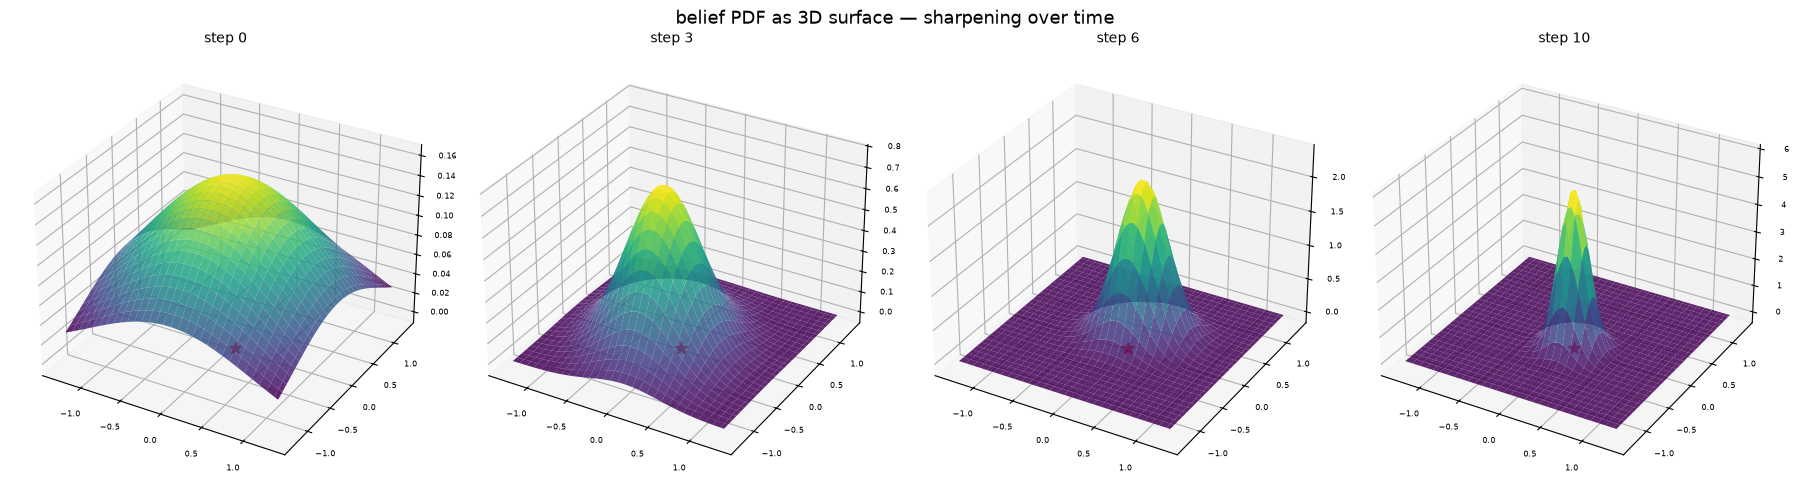

In [23]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_belief_3d(ax, mu, Sigma, step_num, target_xy):
    # grid over the space
    xs = np.linspace(-1.3, 1.3, 60)
    ys = np.linspace(-1.3, 1.3, 60)
    XX, YY = np.meshgrid(xs, ys)
    pos = np.stack([XX, YY], axis=-1)  # (60, 60, 2)
    diff = pos - mu
    Sigma_inv = np.linalg.inv(Sigma)
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    Z = np.exp(exponent) / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    ax.plot_surface(XX, YY, Z, cmap='viridis', alpha=0.85, linewidth=0)
    # mark target on the floor
    ax.scatter([target_xy[0]], [target_xy[1]], [0], c='red', s=80, marker='*')
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.set_zlabel("density", fontsize=8)
    ax.tick_params(labelsize=6)

# show 4 snapshots side by side in 3D
snap_idx = np.linspace(0, len(history["mu"]) - 1, 4).astype(int)
fig = plt.figure(figsize=(18, 5))
for panel, step in enumerate(snap_idx):
    ax = fig.add_subplot(1, 4, panel + 1, projection='3d')
    plot_belief_3d(ax, history["mu"][step], history["Sigma"][step], step, X[target_idx])
fig.suptitle("belief PDF as 3D surface — sharpening over time", fontsize=13)
fig.tight_layout()
plt.show()

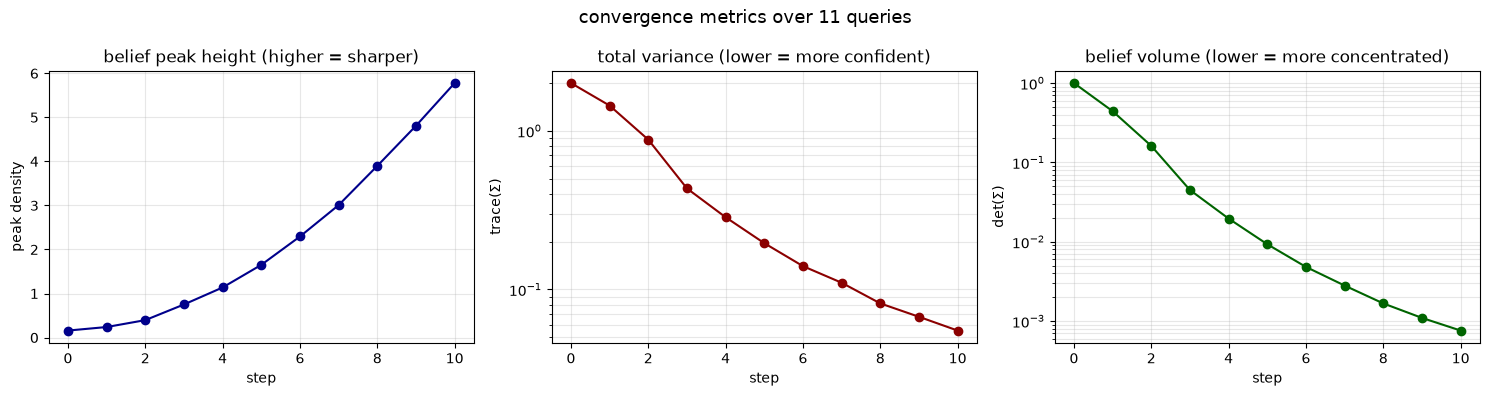

peak density: start=0.159, end=5.779, ratio=36.3x
trace(Σ):    start=2.000, end=0.0551
det(Σ):      start=1.000, end=0.000759


In [24]:
peak_heights = []
trace_Sigma = []
det_Sigma = []
for step in range(len(history["mu"])):
    Sigma = history["Sigma"][step]
    peak_heights.append(1.0 / (2 * np.pi * np.sqrt(np.linalg.det(Sigma))))
    trace_Sigma.append(np.trace(Sigma))
    det_Sigma.append(np.linalg.det(Sigma))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(peak_heights, marker='o', color='darkblue')
axes[0].set_xlabel("step"); axes[0].set_ylabel("peak density")
axes[0].set_title("belief peak height (higher = sharper)")
axes[0].grid(alpha=0.3)

axes[1].plot(trace_Sigma, marker='o', color='darkred')
axes[1].set_xlabel("step"); axes[1].set_ylabel("trace(Σ)")
axes[1].set_title("total variance (lower = more confident)")
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3, which='both')

axes[2].plot(det_Sigma, marker='o', color='darkgreen')
axes[2].set_xlabel("step"); axes[2].set_ylabel("det(Σ)")
axes[2].set_title("belief volume (lower = more concentrated)")
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3, which='both')

fig.suptitle(f"convergence metrics over {history['step_stopped']} queries", fontsize=13)
fig.tight_layout()
plt.show()

print(f"peak density: start={peak_heights[0]:.3f}, end={peak_heights[-1]:.3f}, ratio={peak_heights[-1]/peak_heights[0]:.1f}x")
print(f"trace(Σ):    start={trace_Sigma[0]:.3f}, end={trace_Sigma[-1]:.4f}")
print(f"det(Σ):      start={det_Sigma[0]:.3f}, end={det_Sigma[-1]:.6f}")

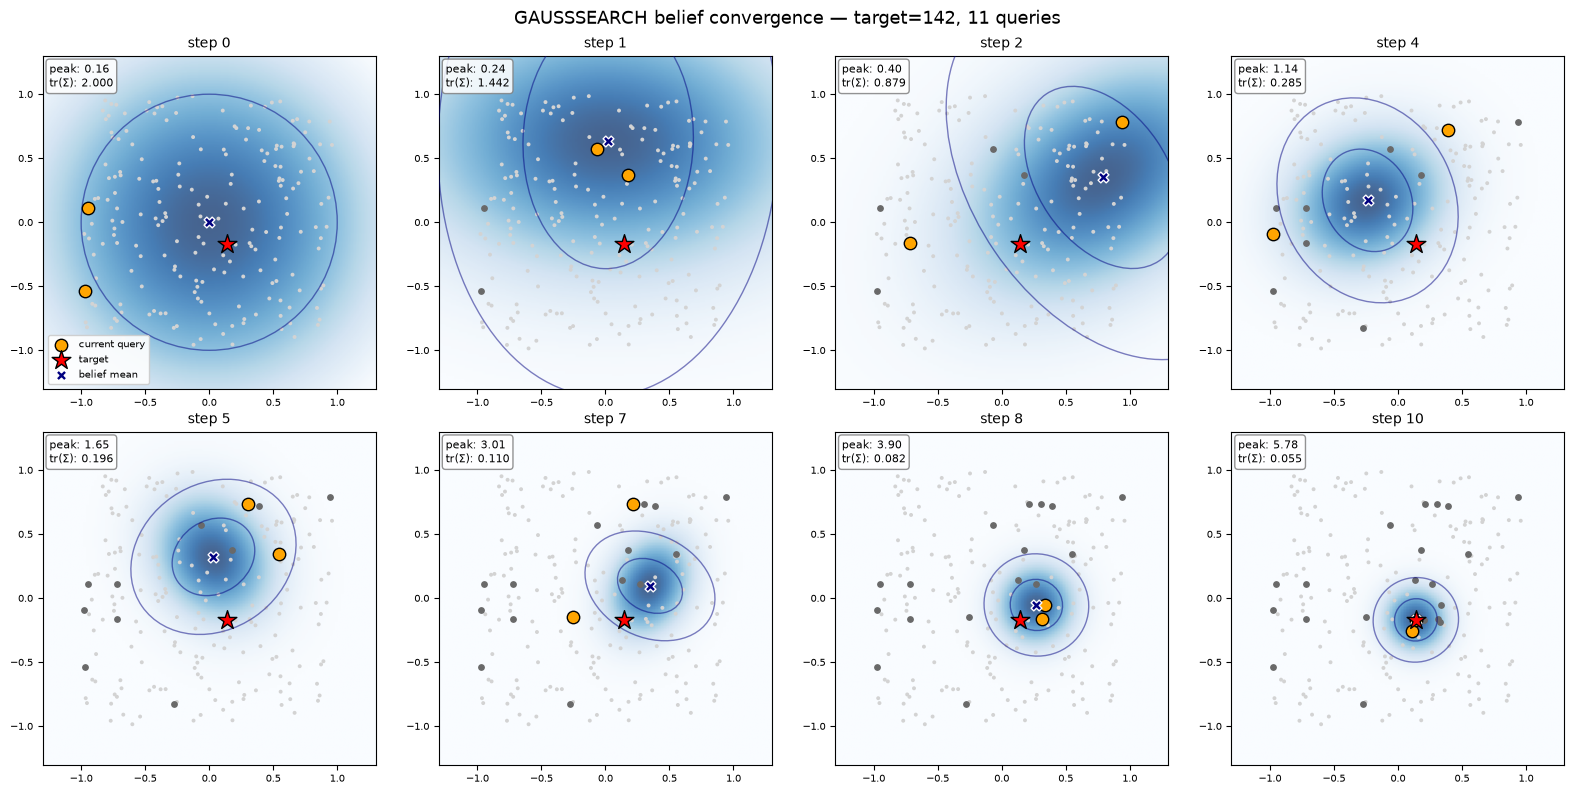

In [25]:
def plot_belief_step_v2(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, step_num):
    # density heatmap as background (Option A)
    xs = np.linspace(-1.3, 1.3, 120)
    ys = np.linspace(-1.3, 1.3, 120)
    XX, YY = np.meshgrid(xs, ys)
    pos = np.stack([XX, YY], axis=-1)
    diff = pos - mu
    Sigma_inv = np.linalg.inv(Sigma)
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    Z = np.exp(exponent) / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    ax.imshow(Z, extent=[-1.3, 1.3, -1.3, 1.3], origin='lower',
              cmap='Blues', alpha=0.75, zorder=0, aspect='equal')
    
    # all items
    ax.scatter(X[:, 0], X[:, 1], s=8, c='lightgray', zorder=1, edgecolors='none')
    
    # used items
    used = set()
    for (i, j) in queries_so_far:
        used.add(i); used.add(j)
    if used:
        used_arr = np.array(list(used))
        ax.scatter(X[used_arr, 0], X[used_arr, 1], s=15, c='dimgray', zorder=2)
    
    # current query pair
    if current_query is not None:
        i, j = current_query
        ax.scatter(X[[i, j], 0], X[[i, j], 1], s=80, c='orange',
                   edgecolors='black', linewidths=1, zorder=4, label='current query')
    
    # target
    ax.scatter(X[target_idx, 0], X[target_idx, 1], s=200, c='red', marker='*',
               edgecolors='black', linewidths=1, zorder=5, label='target')
    
    # belief mean
    ax.scatter(mu[0], mu[1], s=60, c='navy', marker='X',
               edgecolors='white', linewidths=1, zorder=4, label='belief mean')
    
    # 1σ and 2σ ellipse outlines (thin, on top of heatmap for shape reference)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    for n_std in [1, 2]:
        width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
                      facecolor='none', edgecolor='navy', linewidth=1, alpha=0.5, zorder=3)
        ax.add_patch(ell)
    
    # numeric annotation (Option D)
    peak = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    tr = np.trace(Sigma)
    ax.text(0.02, 0.98, f"peak: {peak:.2f}\ntr(Σ): {tr:.3f}",
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.tick_params(labelsize=7)


def render_snapshot_grid_v2(history, X, target_idx, n_snapshots=8):
    n_total = len(history["mu"])
    snap_idx = np.linspace(0, n_total - 1, n_snapshots).astype(int)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for panel, step in enumerate(snap_idx):
        ax = axes[panel]
        mu = history["mu"][step]
        Sigma = history["Sigma"][step]
        queries_so_far = history["queries"][:step]
        current_query = history["queries"][step] if step < len(history["queries"]) else None
        plot_belief_step_v2(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, step)
    axes[0].legend(loc='lower left', fontsize=7, framealpha=0.9)
    fig.suptitle(f"GAUSSSEARCH belief convergence — target={target_idx}, {history['step_stopped']} queries",
                 fontsize=13)
    fig.tight_layout()
    return fig

fig = render_snapshot_grid_v2(history, X, target_idx, n_snapshots=8)
plt.show()

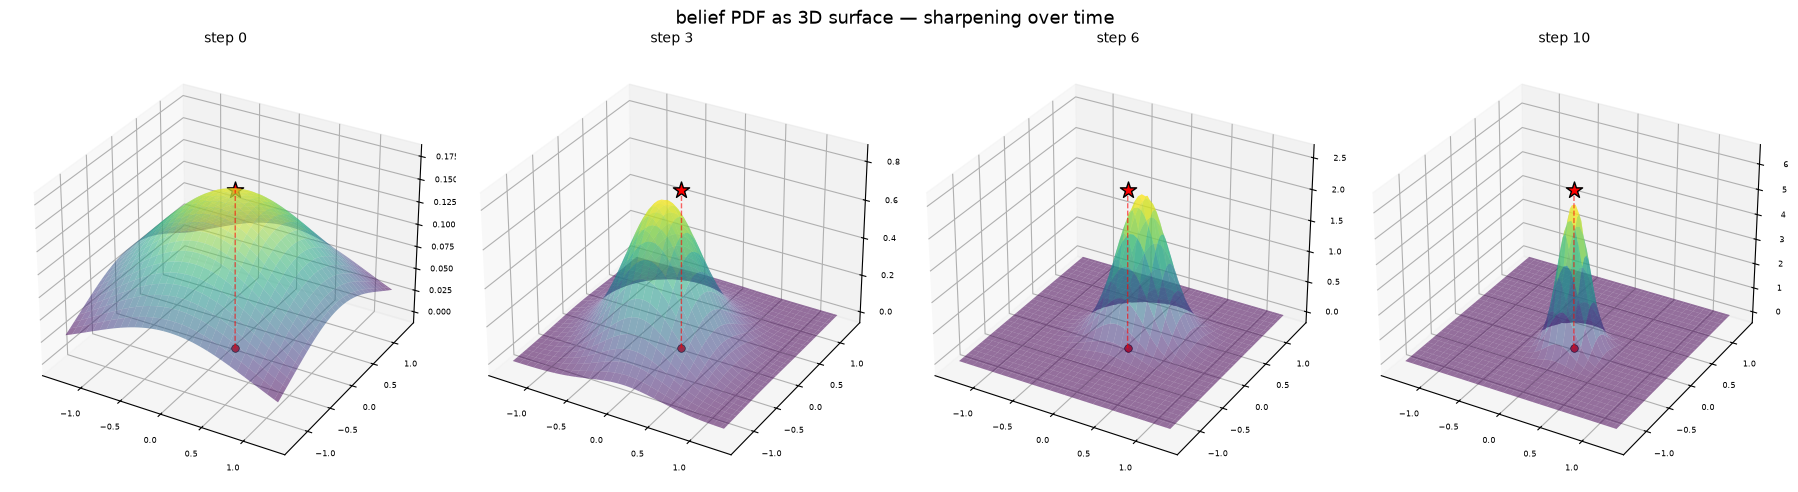

In [26]:
def plot_belief_3d(ax, mu, Sigma, step_num, target_xy):
    xs = np.linspace(-1.3, 1.3, 60)
    ys = np.linspace(-1.3, 1.3, 60)
    XX, YY = np.meshgrid(xs, ys)
    pos = np.stack([XX, YY], axis=-1)
    diff = pos - mu
    Sigma_inv = np.linalg.inv(Sigma)
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    Z = np.exp(exponent) / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    
    # more transparent surface so target is visible through it
    ax.plot_surface(XX, YY, Z, cmap='viridis', alpha=0.55, linewidth=0,
                    antialiased=True, zorder=1)
    
    # target: floating red star at top of the plot's z-range so it's never occluded
    z_top = Z.max() * 1.1
    ax.scatter([target_xy[0]], [target_xy[1]], [z_top],
               c='red', s=150, marker='*', edgecolors='black', linewidths=1,
               depthshade=False, zorder=10)
    # vertical dashed line from target down to floor for spatial anchoring
    ax.plot([target_xy[0], target_xy[0]], [target_xy[1], target_xy[1]], [0, z_top],
            color='red', linestyle='--', linewidth=1, alpha=0.6, zorder=9)
    # small dot on the floor at target location
    ax.scatter([target_xy[0]], [target_xy[1]], [0], c='red', s=30, marker='o',
               edgecolors='black', linewidths=0.5, depthshade=False, zorder=10)
    
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.set_zlabel("density", fontsize=8)
    ax.tick_params(labelsize=6)

# re-render B
snap_idx = np.linspace(0, len(history["mu"]) - 1, 4).astype(int)
fig = plt.figure(figsize=(18, 5))
for panel, step in enumerate(snap_idx):
    ax = fig.add_subplot(1, 4, panel + 1, projection='3d')
    plot_belief_3d(ax, history["mu"][step], history["Sigma"][step], step, X[target_idx])
fig.suptitle("belief PDF as 3D surface — sharpening over time", fontsize=13)
fig.tight_layout()
plt.show()

In [27]:
import matplotlib.animation as animation
from IPython.display import HTML

def make_belief_animation(history, X, target_idx, interval_ms=600):
    n_total = len(history["mu"])
    fig, ax = plt.subplots(figsize=(7, 7))
    
    def draw_frame(step):
        ax.clear()
        mu = history["mu"][step]
        Sigma = history["Sigma"][step]
        queries_so_far = history["queries"][:step]
        current_query = history["queries"][step] if step < len(history["queries"]) else None
        plot_belief_step_v2(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, step)
        if step == 0:
            ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
        return []
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=n_total,
                                    interval=interval_ms, blit=False, repeat=True)
    plt.close(fig)  # prevent duplicate static frame from showing
    return anim

anim = make_belief_animation(history, X, target_idx, interval_ms=600)
HTML(anim.to_jshtml())

C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\matplotlib\animation.py:916: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [28]:
import matplotlib.animation as animation

def make_belief_animation_v2(history, X, target_idx, sigma_eps, interval_ms=2000):
    n_total = len(history["mu"])
    fig, ax = plt.subplots(figsize=(8, 8))
    
    def draw_frame(step):
        ax.clear()
        mu = history["mu"][step]
        Sigma = history["Sigma"][step]
        queries_so_far = history["queries"][:step]
        current_query = history["queries"][step] if step < len(history["queries"]) else None
        current_answer = history["answers"][step] if step < len(history["answers"]) else None
        plot_belief_step_v3(ax, X, target_idx, mu, Sigma, queries_so_far,
                            current_query, current_answer, step, sigma_eps)
        return []
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=n_total,
                                    interval=interval_ms, blit=False, repeat=True)
    plt.close(fig)
    return anim

In [29]:
def plot_belief_step_v3(ax, X, target_idx, mu, Sigma, queries_so_far, current_query, 
                        current_answer, step_num, sigma_eps):
    # density heatmap
    xs = np.linspace(-1.3, 1.3, 120)
    ys = np.linspace(-1.3, 1.3, 120)
    XX, YY = np.meshgrid(xs, ys)
    pos = np.stack([XX, YY], axis=-1)
    diff = pos - mu
    Sigma_inv = np.linalg.inv(Sigma)
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    Z = np.exp(exponent) / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    ax.imshow(Z, extent=[-1.3, 1.3, -1.3, 1.3], origin='lower',
              cmap='Blues', alpha=0.75, zorder=0, aspect='equal')
    
    # all unused items
    ax.scatter(X[:, 0], X[:, 1], s=8, c='lightgray', zorder=1, edgecolors='none')
    
    # past used items (excluding current query)
    used = set()
    for (i, j) in queries_so_far:
        used.add(i); used.add(j)
    if current_query is not None:
        used.discard(current_query[0])
        used.discard(current_query[1])
    if used:
        used_arr = np.array(list(used))
        ax.scatter(X[used_arr, 0], X[used_arr, 1], s=15, c='dimgray', zorder=2)
    
    # current query pair
    query_info = ""
    if current_query is not None and current_answer is not None:
        i, j = current_query
        chosen_idx = i if current_answer == 0 else j
        rejected_idx = j if current_answer == 0 else i
        ax.scatter(X[chosen_idx, 0], X[chosen_idx, 1], s=140, c='limegreen',
                   edgecolors='black', linewidths=1.5, zorder=4)
        ax.scatter(X[rejected_idx, 0], X[rejected_idx, 1], s=90, c='sandybrown',
                   edgecolors='black', linewidths=1, zorder=4)
        p_i = probit_prob(X[i], X[j], X[target_idx], sigma_eps)
        p_chosen = p_i if current_answer == 0 else (1 - p_i)
        query_info = f"P(chosen | correct): {p_chosen:.2f}"
    elif current_query is not None:
        i, j = current_query
        ax.scatter(X[[i, j], 0], X[[i, j], 1], s=100, c='sandybrown',
                   edgecolors='black', linewidths=1, zorder=4)
    
    # target
    ax.scatter(X[target_idx, 0], X[target_idx, 1], s=200, c='red', marker='*',
               edgecolors='black', linewidths=1, zorder=5)
    
    # belief mean
    ax.scatter(mu[0], mu[1], s=60, c='navy', marker='X',
               edgecolors='white', linewidths=1, zorder=4)
    
    # ellipses
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    for n_std in [1, 2]:
        width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
                      facecolor='none', edgecolor='navy', linewidth=1, alpha=0.5, zorder=3)
        ax.add_patch(ell)
    
    # annotations
    dist_to_target = np.linalg.norm(mu - X[target_idx])
    peak = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    ann_text = f"‖µ - target‖: {dist_to_target:.3f}\npeak: {peak:.2f}"
    if query_info:
        ann_text += f"\n{query_info}"
    ax.text(0.02, 0.98, ann_text,
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.tick_params(labelsize=7)


def make_belief_animation_v2(history, X, target_idx, sigma_eps, interval_ms=2000):
    from matplotlib.lines import Line2D
    n_total = len(history["mu"])
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # fixed legend handles — never change frame to frame
    legend_handles = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='red',
               markersize=14, markeredgecolor='black', label='target'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='navy',
               markersize=10, markeredgecolor='white', label='belief mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',
               markersize=11, markeredgecolor='black', label='chosen this turn'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='sandybrown',
               markersize=9, markeredgecolor='black', label='not chosen'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='dimgray',
               markersize=6, label='past queries'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markersize=5, label='unused items'),
    ]
    
    def draw_frame(step):
        ax.clear()
        mu = history["mu"][step]
        Sigma = history["Sigma"][step]
        queries_so_far = history["queries"][:step]
        current_query = history["queries"][step] if step < len(history["queries"]) else None
        current_answer = history["answers"][step] if step < len(history["answers"]) else None
        plot_belief_step_v3(ax, X, target_idx, mu, Sigma, queries_so_far,
                            current_query, current_answer, step, sigma_eps)
        # legend on every frame with fixed handles
        ax.legend(handles=legend_handles, loc='lower left', fontsize=7, framealpha=0.9)
        return []
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=n_total,
                                    interval=interval_ms, blit=False, repeat=True)
    plt.close(fig)
    return anim

anim = make_belief_animation_v2(history, X, target_idx, SIGMA_EPS, interval_ms=2000)



In [30]:
!pip install imageio-ffmpeg

In [31]:
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
print("ffmpeg path:", matplotlib.rcParams['animation.ffmpeg_path'])

ffmpeg path: C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [33]:
import uuid,os,tempfile
from IPython.display import Video

# rebuild anim fresh
anim = make_belief_animation_v2(history, X, target_idx, SIGMA_EPS, interval_ms=2000)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"belief_anim_{uuid.uuid4().hex[:8]}.mp4")
anim.save(tmp_mp4, writer='ffmpeg', fps=0.5, dpi=100)
print(f"saved to {tmp_mp4}")

Video(tmp_mp4, embed=True, width=600)

saved to C:\Users\shlok\AppData\Local\Temp\belief_anim_9b41b8fe.mp4


In [34]:
import shutil
shutil.copy(tmp_mp4, "../plots/gauss_search_convergence.mp4")

'../plots/gauss_search_convergence.mp4'

In [35]:
import uuid
from IPython.display import Video

# rebuild 3D anim fresh
anim_3d = make_3d_animation(history, X, target_idx, interval_ms=2000)

tmp_mp4_3d = os.path.join(tempfile.gettempdir(), f"belief_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4_3d, writer='ffmpeg', fps=0.5, dpi=100)
print(f"saved to {tmp_mp4_3d}")

Video(tmp_mp4_3d, embed=True, width=700)

saved to C:\Users\shlok\AppData\Local\Temp\belief_3d_eebf3791.mp4


In [36]:
def plot_belief_3d(ax, mu, Sigma, step_num, target_xy):
    xs = np.linspace(-1.3, 1.3, 60)
    ys = np.linspace(-1.3, 1.3, 60)
    XX, YY = np.meshgrid(xs, ys)
    pos = np.stack([XX, YY], axis=-1)
    diff = pos - mu
    Sigma_inv = np.linalg.inv(Sigma)
    exponent = -0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    Z = np.exp(exponent) / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    
    ax.plot_surface(XX, YY, Z, cmap='viridis', alpha=0.55, linewidth=0,
                    antialiased=True, zorder=1)
    
    # target — floating red star at top
    z_top = Z.max() * 1.1
    ax.scatter([target_xy[0]], [target_xy[1]], [z_top],
               c='red', s=150, marker='*', edgecolors='black', linewidths=1,
               depthshade=False, zorder=10)
    ax.plot([target_xy[0], target_xy[0]], [target_xy[1], target_xy[1]], [0, z_top],
            color='red', linestyle='--', linewidth=1, alpha=0.6, zorder=9)
    ax.scatter([target_xy[0]], [target_xy[1]], [0], c='red', s=30, marker='o',
               edgecolors='black', linewidths=0.5, depthshade=False, zorder=10)
    
    # belief mean — navy X at the peak
    peak_z = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    ax.scatter([mu[0]], [mu[1]], [peak_z],
               c='navy', s=120, marker='X', edgecolors='white', linewidths=1.5,
               depthshade=False, zorder=11)
    # dashed line from mean to floor
    ax.plot([mu[0], mu[0]], [mu[1], mu[1]], [0, peak_z],
            color='navy', linestyle='--', linewidth=1, alpha=0.6, zorder=9)
    # small dot on the floor at belief mean
    ax.scatter([mu[0]], [mu[1]], [0], c='navy', s=30, marker='o',
               edgecolors='white', linewidths=0.5, depthshade=False, zorder=10)
    
    ax.set_title(f"step {step_num}", fontsize=10)
    ax.set_zlabel("density", fontsize=8)
    ax.tick_params(labelsize=6)

In [37]:
import uuid
from IPython.display import Video

anim_3d = make_3d_animation(history, X, target_idx, interval_ms=2000)

tmp_mp4_3d = os.path.join(tempfile.gettempdir(), f"belief_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4_3d, writer='ffmpeg', fps=0.5, dpi=100)
Video(tmp_mp4_3d, embed=True, width=700)

C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\matplotlib\animation.py:916: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [38]:
import shutil

shutil.copy(tmp_mp4_3d, "../plots/gauss_search_3d.mp4")
print("saved to ../plots/gauss_search_3d.mp4")

saved to ../plots/gauss_search_3d.mp4


In [39]:
!dir ..\plots

 Volume in drive C is Windows
 Volume Serial Number is 20B4-6D61

 Directory of C:\Users\shlok\projects\ddp-llm\gamma-ckl\plots

25-07-2026  11:53    <DIR>          .
09-07-2026  13:40    <DIR>          ..
14-08-2026  03:40           200,365 gauss_search_3d.mp4
14-08-2026  03:40           161,587 gauss_search_convergence.mp4
               2 File(s)        361,952 bytes
               2 Dir(s)  675,473,887,232 bytes free
